In [1]:
# Data handling
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Utility
import random

import shutil
import random




In [2]:
base_path = "data/garbage_classification"

for category in os.listdir(base_path):
    print(category, ":", len(os.listdir(os.path.join(base_path, category))))

cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137


In [3]:
source_dir = "data/garbage_classification"
train_dir = "data/train"
test_dir = "data/test"

if os.path.exists(train_dir):
    shutil.rmtree(train_dir)

if os.path.exists(test_dir):
    shutil.rmtree(test_dir)

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    files = os.listdir(class_path)
    random.shuffle(files)

    split = int(0.8 * len(files))

    train_files = files[:split]
    test_files = files[split:]

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    for f in train_files:
        shutil.copy(
            os.path.join(class_path, f),
            os.path.join(train_dir, class_name, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(class_path, f),
            os.path.join(test_dir, class_name, f)
        )

print("Data split completed successfully!")

Data split completed successfully!


In [4]:
print("\nTRAIN DATA:")
for category in os.listdir(train_dir):
    count = len(os.listdir(os.path.join(train_dir, category)))
    print(category, ":", count)

print("\nTEST DATA:")
for category in os.listdir(test_dir):
    count = len(os.listdir(os.path.join(test_dir, category)))
    print(category, ":", count)


TRAIN DATA:
cardboard : 322
glass : 400
metal : 328
paper : 475
plastic : 385
trash : 109

TEST DATA:
cardboard : 81
glass : 101
metal : 82
paper : 119
plastic : 97
trash : 28


In [5]:
for category in os.listdir(source_dir):
    print(category, ":", len(os.listdir(os.path.join(source_dir, category))))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    "data/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)    

cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137
Found 2019 images belonging to 6 classes.
Found 508 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [6]:
y_train = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: 1.045031055900621, 1: 0.84125, 2: 1.0259146341463414, 3: 0.708421052631579, 4: 0.874025974025974, 5: 3.0871559633027523}


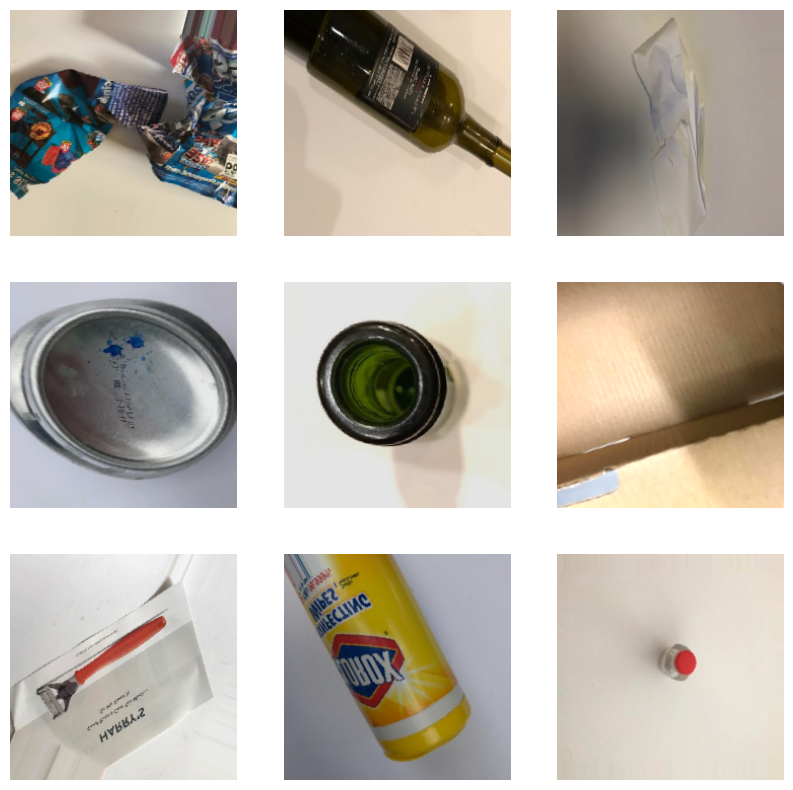

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()

[('cardboard', 403), ('glass', 501), ('metal', 410), ('paper', 594), ('plastic', 482), ('trash', 137)]


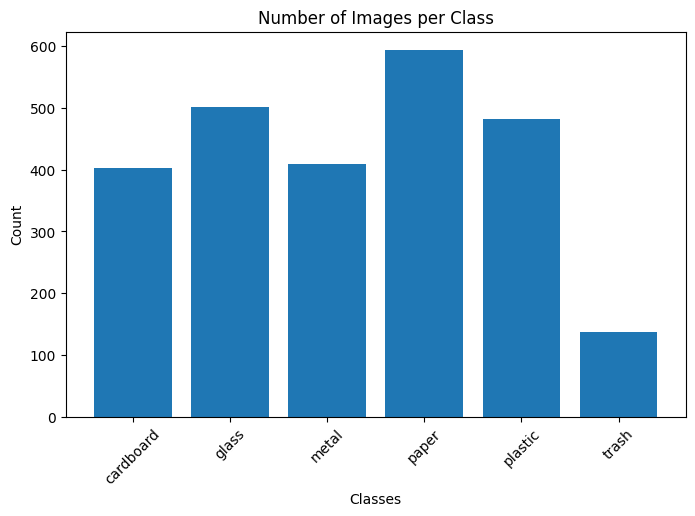

In [8]:
#images per category
categories = []
counts = []

for category in os.listdir(source_dir):
    path = os.path.join(source_dir, category)
    categories.append(category)
    counts.append(len(os.listdir(path)))

print(list(zip(categories, counts)))

plt.figure(figsize=(8,5))
plt.bar(categories, counts)
plt.xticks(rotation=45)
plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

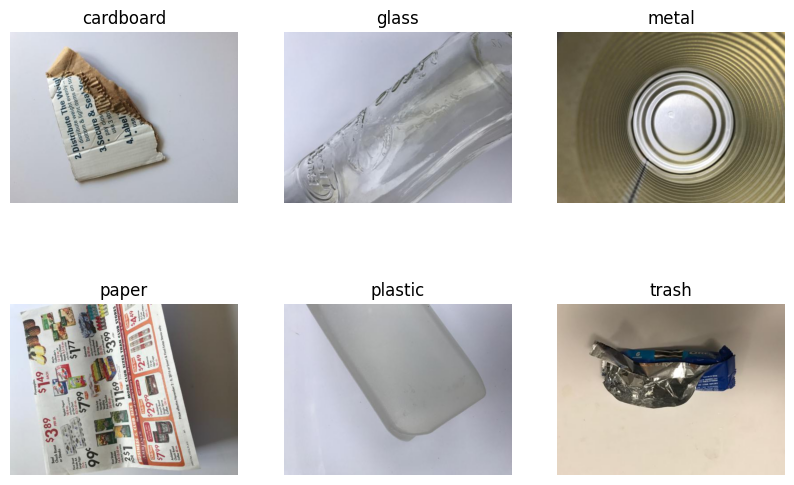

In [9]:
#Sample Images per Class
plt.figure(figsize=(10,10))

for i, category in enumerate(categories):
    folder = os.path.join(source_dir, category)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.show()

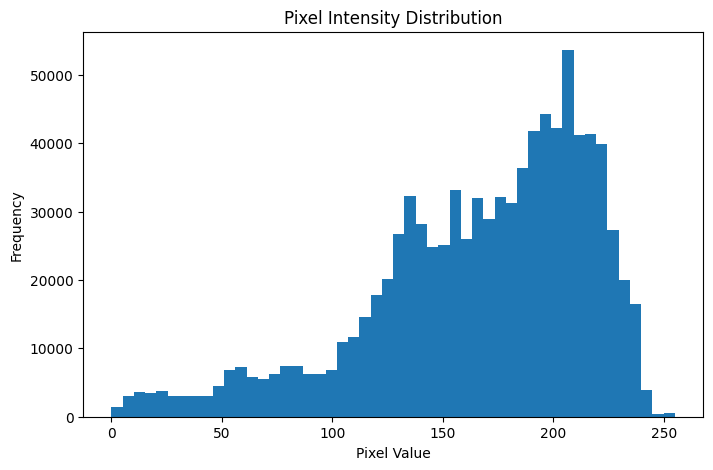

In [10]:
#Pixel Intensity Distribution
sample_images = []

for category in categories:
    folder = os.path.join(source_dir, category)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path).resize((224,224))
    img_array = np.array(img)

    sample_images.append(img_array)

sample_images = np.array(sample_images)

plt.figure(figsize=(8,5))

plt.hist(sample_images.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()



Epoch 1/15


64/64 [==============================] - 55s 817ms/step - loss: 1.7244 - accuracy: 0.4344 - val_loss: 1.1700 - val_accuracy: 0.5374
Epoch 2/15
64/64 [==============================] - 22s 349ms/step - loss: 1.0346 - accuracy: 0.6379 - val_loss: 1.2293 - val_accuracy: 0.5354
Epoch 3/15
64/64 [==============================] - 22s 348ms/step - loss: 0.7643 - accuracy: 0.7231 - val_loss: 1.2149 - val_accuracy: 0.5728
Epoch 4/15
64/64 [==============================] - 25s 391ms/step - loss: 0.6769 - accuracy: 0.7528 - val_loss: 1.5680 - val_accuracy: 0.5650
Epoch 5/15
64/64 [==============================] - 24s 370ms/step - loss: 0.5476 - accuracy: 0.8034 - val_loss: 1.3933 - val_accuracy: 0.6004
Epoch 6/15
64/64 [==============================] - 24s 372ms/step - loss: 0.4973 - accuracy: 0.8083 - val_loss: 1.3622 - val_accuracy: 0.6280
Epoch 7/15
64/64 [==============================] - 26s 405ms/step - loss: 0.4087 - accuracy: 0.8460 - val_loss: 1.3767 - val_accuracy: 0.

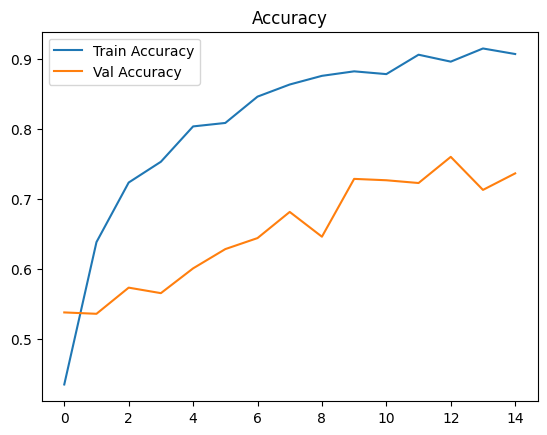

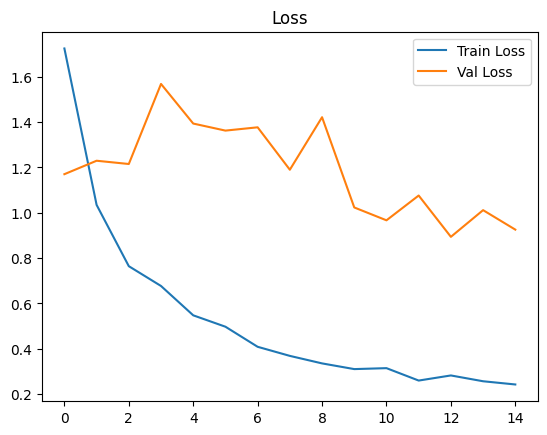

In [11]:
# MobileNetV2 Model

base_model_m = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_m.trainable = True
for layer in base_model_m.layers[:-20]:
    layer.trainable = False

model_m = models.Sequential([
    base_model_m,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')   # 6 classes
])

model_m.compile(
    optimizer=Adam(learning_rate=0.0001),   # 🔥 IMPORTANT
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_m = model_m.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights
)

plt.plot(history_m.history['accuracy'], label='Train Accuracy')
plt.plot(history_m.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history_m.history['loss'], label='Train Loss')
plt.plot(history_m.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()  

In [12]:
val_generator.reset()

y_pred_m = model_m.predict(val_generator)   # or model_m
y_pred_classes = np.argmax(y_pred_m, axis=1)

y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

16/16 [==============================] - 3s 137ms/step


[[70  0  0  5  4  2]
 [ 0 55  2  0 44  0]
 [ 0  4 48  0 27  3]
 [ 0  1  0 89 23  6]
 [ 0  2  0  1 94  0]
 [ 0  2  0  1  7 18]]


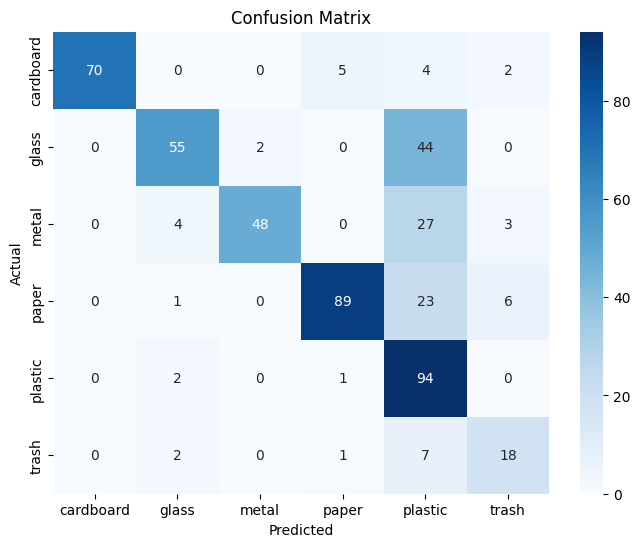

In [13]:
cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

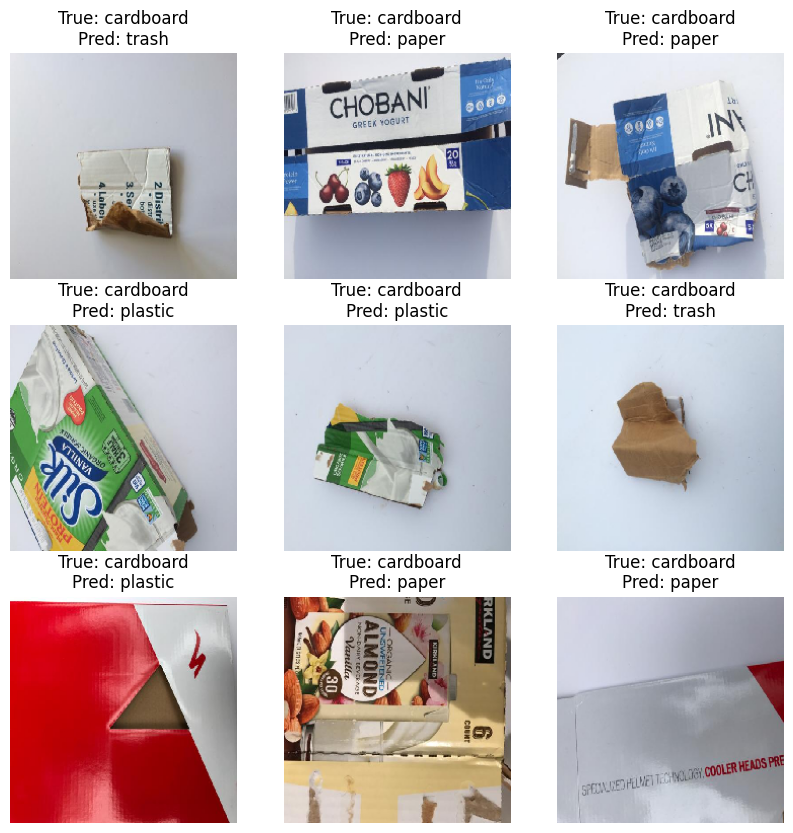

16/16 [==============================] - 2s 143ms/step - loss: 0.9255 - accuracy: 0.7362
Validation Accuracy: 0.7362204790115356


In [14]:
filepaths = val_generator.filepaths

errors = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(10,10))

for i, idx in enumerate(errors[:9]):
    img_path = filepaths[idx]

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0

    plt.subplot(3,3,i+1)
    plt.imshow(img_array)
    plt.title(f"True: {class_labels[y_true[idx]]}\nPred: {class_labels[y_pred_classes[idx]]}")
    plt.axis('off')

plt.show()

loss, accuracy = model_m.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

In [15]:
# ResNet50 Model

base_model_r = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_r.trainable = True
for layer in base_model_r.layers[:-20]:
    layer.trainable = False

model_r = models.Sequential([
    base_model_r,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model_r.compile(
    optimizer=Adam(learning_rate=0.0001),   # 🔥 IMPORTANT
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_r = model_r.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
64/64 [==============================] - 81s 1s/step - loss: 2.0525 - accuracy: 0.2779 - val_loss: 1.9646 - val_accuracy: 0.1614
Epoch 2/15
64/64 [==============================] - 81s 1s/step - loss: 1.8136 - accuracy: 0.3492 - val_loss: 1.7688 - val_accuracy: 0.2146
Epoch 3/15
64/64 [==============================] - 75s 1s/step - loss: 1.7605 - accuracy: 0.3447 - val_loss: 1.7714 - val_accuracy: 0.2126
Epoch 4/15
64/64 [==============================] - 82s 1s/step - loss: 1.6311 - accuracy: 0.3730 - val_loss: 1.7622 - val_accuracy: 0.1693
Epoch 5/15
64/64 [==============================] - 272s 4s/step - loss: 1.5367 - accuracy: 0.4027 - val_loss: 1.6318 - val_accuracy: 0.2776
Epoch 6/15
64/64 [==============================] - 74s 1s/step - loss: 1.4849 - accuracy: 0.4180 - val_loss: 1.6209 - val_accuracy: 0.3268
Epoch 7/15
64/64 [==============================] - 93s 1s/step - loss: 1.4564 - accuracy: 0.4354 - val_loss: 1.8630 - val_accuracy: 0.2362
Epoch 8/15
64/64 [=

In [16]:
val_generator.reset()

y_pred_r = model_r.predict(val_generator)   # or model_m
y_pred_classes = np.argmax(y_pred_r, axis=1)

y_true = val_generator.classes

print(classification_report(y_true, y_pred_classes))

16/16 [==============================] - 13s 759ms/step
              precision    recall  f1-score   support

           0       0.24      0.86      0.38        81
           1       0.50      0.03      0.06       101
           2       0.00      0.00      0.00        82
           3       0.51      0.44      0.47       119
           4       0.00      0.00      0.00        97
           5       0.13      0.54      0.21        28

    accuracy                           0.28       508
   macro avg       0.23      0.31      0.19       508
weighted avg       0.26      0.28      0.19       508



d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [17]:
val_generator.reset()

y_pred_m = model_m.predict(val_generator)
y_pred_m = np.argmax(y_pred_m, axis=1)


y_pred_r = model_r.predict(val_generator)
y_pred_r = np.argmax(y_pred_r, axis=1)

y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

report_m = classification_report(y_true, y_pred_m, target_names=class_labels, output_dict=True)

report_r = classification_report(y_true, y_pred_r, target_names=class_labels, output_dict=True)

f1_m = report_m['weighted avg']['f1-score']
f1_r = report_r['weighted avg']['f1-score']

16/16 [==============================] - 12s 783ms/step


d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [18]:

loss_r, acc_r = model_r.evaluate(val_generator)

results = pd.DataFrame({
    "Model": ["MobileNetV2", "ResNet50"],
    "Accuracy": [accuracy, acc_r],
    "F1-score": [f1_m, f1_r]
})

print(results)

best_model = results.loc[results['F1-score'].idxmax()]

print("Best Model:")
print(best_model)

model_m.save("models/best_model.h5")

16/16 [==============================] - 14s 920ms/step - loss: 3.0555 - accuracy: 0.2756
         Model  Accuracy  F1-score
0  MobileNetV2  0.736220  0.747800
1     ResNet50  0.275591  0.193691
Best Model:
Model       MobileNetV2
Accuracy        0.73622
F1-score         0.7478
Name: 0, dtype: object


d:\Guvi\Projects\garbage-classification\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
